In [1]:
from decluttering.data.utils.dino_dataloader import DinoDataloader
import torch

device = 'cuda:0'

dino_dataloader = DinoDataloader(
            # image_list=images,
            device=device,
            cfg={"image_shape": [644, 1022]},
            # cache_path=dino_cache_path,
        )

def tt2dino(tt_frame, dino_downscale_factor=1):
    # Takes tensor image in shape (H, W, C) and returns dino embeddings in shape (H, W, 384)
    im = tt_frame.permute(2, 0, 1).to(torch.float32)
    print(im.shape)
    dino_dataloader.generate_dino_embed(im)
    H, W = im.shape[1:]
    # scale = torch.tensor(0.1).to(device)
    scaled_height = H//dino_downscale_factor
    scaled_width = W//dino_downscale_factor

    x = torch.arange(0, scaled_width*dino_downscale_factor, dino_downscale_factor).view(1, scaled_width, 1).expand(scaled_height, scaled_width, 1).to(device)
    y = torch.arange(0, scaled_height*dino_downscale_factor, dino_downscale_factor).view(scaled_height, 1, 1).expand(scaled_height, scaled_width, 1).to(device)
    image_idx_tensor = torch.zeros(scaled_height, scaled_width, 1).to(device)
    positions = torch.cat((image_idx_tensor, y, x), dim=-1).view(-1, 3).to(int)
    # print(positions.device)
    with torch.no_grad():
        data = dino_dataloader(positions.cpu()).view(H, W, -1)
    return data

torch.Size([644, 1022, 3])


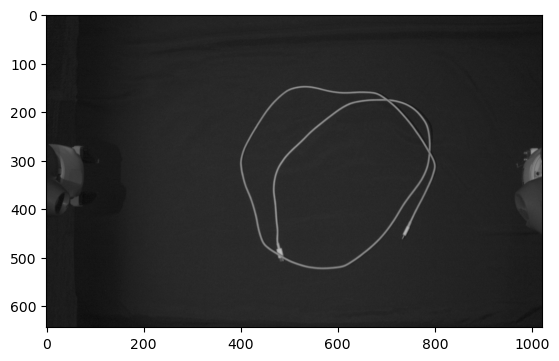

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
im_frame1 = Image.open('/home/justinyu/multicable-decluttering/misc_images/raw.png')
np_frame1 = np.array(im_frame1)

# remove alpha channel
np_frame1 = np_frame1[0:644, 0:1022, :3] # Must resize for DINO's 14-pixel patch size
tt_frame1 = torch.tensor(np_frame1).to(torch.uint8)
print(tt_frame1.shape)
plt.imshow(np_frame1)


In [3]:

embed = tt2dino(tt_frame1)
print(embed.shape)

torch.Size([3, 644, 1022])


Using cache found in /home/justinyu/.cache/torch/hub/facebookresearch_dinov2_main
/home/justinyu/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/justinyu/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/justinyu/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


644
torch.Size([1, 3, 644, 1022])
DinoEmbeddingProcess took 1.2629644870758057 seconds
torch.Size([644, 1022, 384])


/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


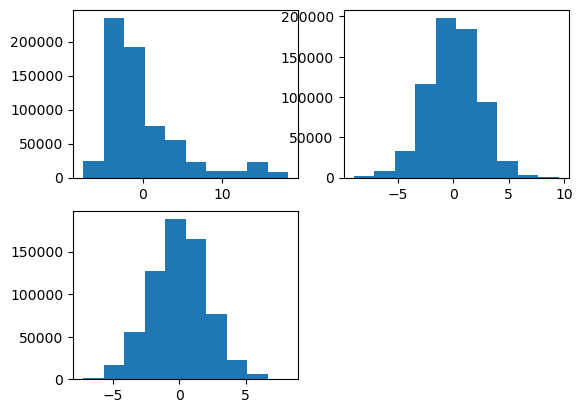

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
total_features = embed.unsqueeze(0).cpu().numpy()
patch_h = 644
patch_w = 1022
feat_dim = 384
# First PCA to Seperate Background
# sklearn expects 2d array for traning
total_features = total_features.reshape(patch_h * patch_w, feat_dim) #4(*H*w, 1024)

pca = PCA(n_components=3)
pca.fit(total_features)
pca_features = pca.transform(total_features)

# visualize PCA components for finding a proper threshold
# 3 histograms for 3 components
plt.subplot(2, 2, 1)
plt.hist(pca_features[:, 0])
plt.subplot(2, 2, 2)
plt.hist(pca_features[:, 1])
plt.subplot(2, 2, 3)
plt.hist(pca_features[:, 2])
plt.show()
plt.close()

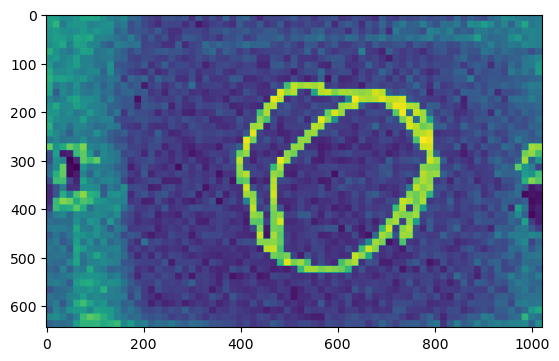

In [5]:
# min_max scale
pca_features[:, 0] = (pca_features[:, 0] - pca_features[:, 0].min()) / \
                     (pca_features[:, 0].max() - pca_features[:, 0].min())
#pca_features = sklearn.processing.minmax_scale(pca_features)

# for i in range(4):
#     plt.subplot(2, 2, i+1)
plt.imshow(pca_features[0*patch_h*patch_w : (1)*patch_h*patch_w, 0].reshape(patch_h, patch_w))

plt.show()

(644, 1022)


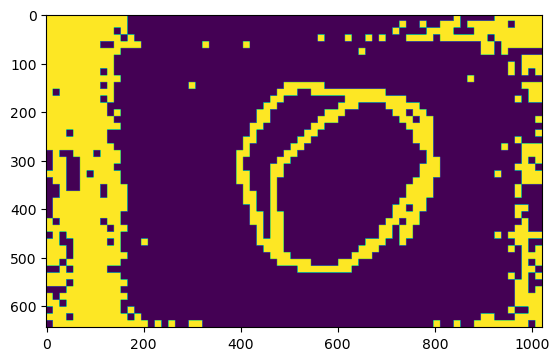

In [6]:

# segment/seperate the backgound and foreground using the first component
pca_features_bg = pca_features[:, 0] > 0.35 # from first histogram
pca_features_fg = ~pca_features_bg

# plot the pca_features_bg
# for i in range(4):
#     plt.subplot(2, 2, i+1)
cable_noisy_mask = pca_features_bg[0 * patch_h * patch_w: (0+1) * patch_h * patch_w].reshape(patch_h, patch_w)
print(cable_noisy_mask.shape)
plt.imshow(cable_noisy_mask)
plt.show()


In [7]:
import cv2
def find_connected_components(binary_image):
    """
    Finds connected components in a binary image.

    Parameters:
    - binary_image: A binary image (numpy array) where the foreground is True and the background is False.

    Returns:
    - num_labels: Number of connected components found (including the background as a label).
    - labels: A labeled image where each connected component is assigned a unique label.
    - stats: Statistics on each connected component (bounding box, area, etc.).
    - centroids: Centroids of each connected component.
    """
    # Ensure the image is of type uint8
    binary_image = binary_image.astype(np.uint8) * 255

    # Find connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_image, connectivity=8)

    return num_labels, labels, stats, centroids

def plot_connected_components(binary_image):
    # Find connected components
    num_labels, labels, stats, centroids = find_connected_components(binary_image)

    # Create an output image to display the components
    output_image = np.zeros((binary_image.shape[0], binary_image.shape[1], 3), dtype=np.uint8)

    # Define colors for each component
    colors = plt.cm.get_cmap('hsv', num_labels)

    for label in range(1, num_labels):  # Skip the background label 0
        mask = labels == label
        output_image[mask] = (np.array(colors(label)[:3]) * 255).astype(np.uint8)

    # Plot the original binary image and the output image with connected components
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(binary_image, cmap='gray')
    ax[0].set_title('Original Binary Image')
    ax[0].axis('off')

    ax[1].imshow(output_image)
    ax[1].set_title('Connected Components')
    ax[1].axis('off')

    plt.show()

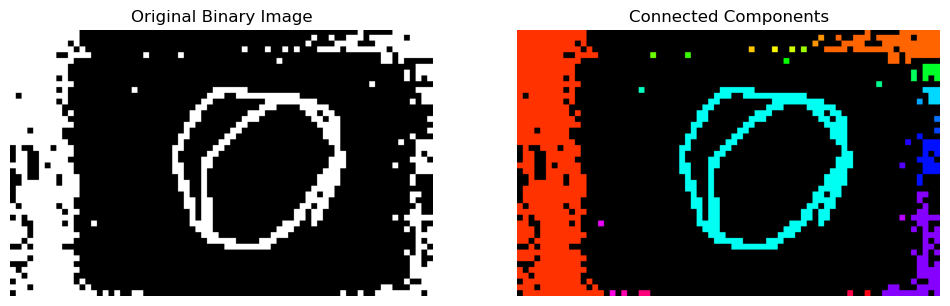

In [8]:
plot_connected_components(cable_noisy_mask)

31
1   88592
2   12740
3   392
4   196
5   196
6   196
7   196
8   196
9   196
10   196
11   1568
12   392
13   196
14   196
15   40376
16   1372
17   196
18   196
19   196
20   3920
21   196
22   196
23   11172
24   196
25   196
26   196
27   196
28   392
29   196
30   196


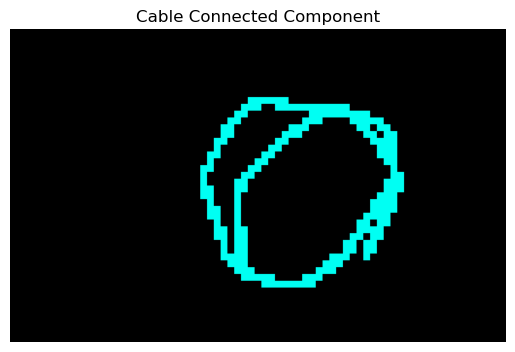

In [9]:
num_labels, labels, stats, centroids = find_connected_components(cable_noisy_mask)

# Create an output image to display the components
output_image = np.zeros((cable_noisy_mask.shape[0], cable_noisy_mask.shape[1], 3), dtype=np.uint8)

# Define colors for each component
colors = plt.cm.get_cmap('hsv', num_labels)
print(num_labels)
for label in range(1, num_labels):  # Skip the background label 0
    mask = labels == label
    print(label, " ", np.sum(mask))

label = 15
mask = labels == label
output_image[mask] = (np.array(colors(label)[:3]) * 255).astype(np.uint8)

plt.title('Cable Connected Component')
plt.axis('off')
plt.imshow(output_image)


In [10]:
print(embed.shape)
print(torch.from_numpy(mask).shape)

embed_copy = embed.cpu().detach()
binary_mask = torch.from_numpy(mask).unsqueeze(-1)

# Apply the mask to the tensor
# masked_tensor = embed_copy * binary_mask

# Get average embedding vector of all pixels in the mask
masked_tensor = embed_copy.view(-1, 384)[torch.from_numpy(mask).view(-1)]
cable_avg_embedding = torch.mean(masked_tensor, dim=0)


torch.Size([644, 1022, 384])
torch.Size([644, 1022])


torch.Size([658168, 384])
torch.Size([1, 384])


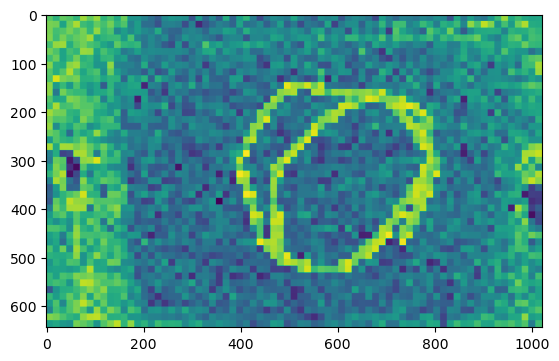

In [11]:
# Cosine similarity between the average embedding and all embeddings
print(embed_copy.view(-1, 384).shape)
print(cable_avg_embedding.unsqueeze(0).shape)
cos = torch.nn.CosineSimilarity(dim=1)
cosine_similarities = cos(embed_copy.view(-1, 384), cable_avg_embedding.unsqueeze(0)).view(644, 1022)

# Plot the cosine similarity image
plt.imshow(cosine_similarities)


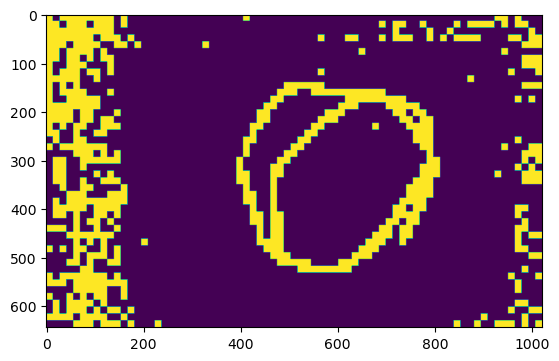

In [12]:
#threshold the cosine similarity image
threshold = 0.95
cable_mask = cosine_similarities > threshold
plt.imshow(cable_mask)


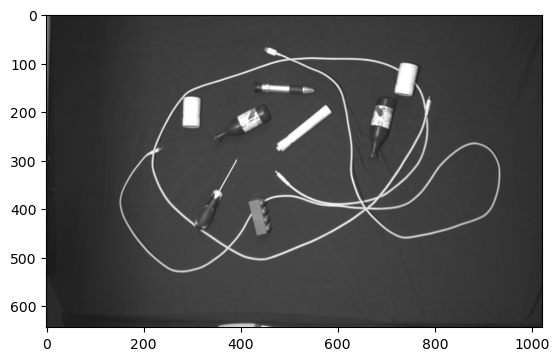

In [13]:
# /home/justinyu/multicable-decluttering/decluttering/scripts/test/raw_images/intensity_image2024-06-25T22:27:15.207858.png
im_frame2 = Image.open('/home/justinyu/multicable-decluttering/decluttering/scripts/test/raw_images/intensity_image2024-06-25T22:27:15.207858.png')
np_frame2 = np.array(im_frame2)

# remove alpha channel
np_frame2 = np_frame2[0:644, 0:1022, :3] # Must resize for DINO's 14-pixel patch size
tt_frame2 = torch.tensor(np_frame2).to(torch.uint8)
plt.imshow(np_frame2)

torch.Size([3, 644, 1022])


Using cache found in /home/justinyu/.cache/torch/hub/facebookresearch_dinov2_main


644
torch.Size([1, 3, 644, 1022])
DinoEmbeddingProcess took 0.0025942325592041016 seconds


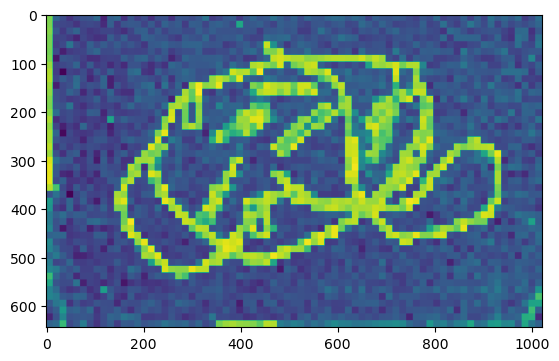

In [14]:

embed2 = tt2dino(tt_frame2)

# Cosine similarity between the average embedding and all embeddings
embed2_copy = embed2.cpu().detach()
cosine_similarities2 = cos(embed2_copy.view(-1, 384), cable_avg_embedding.unsqueeze(0)).view(644, 1022)

# Plot the cosine similarity image
plt.imshow(cosine_similarities2)

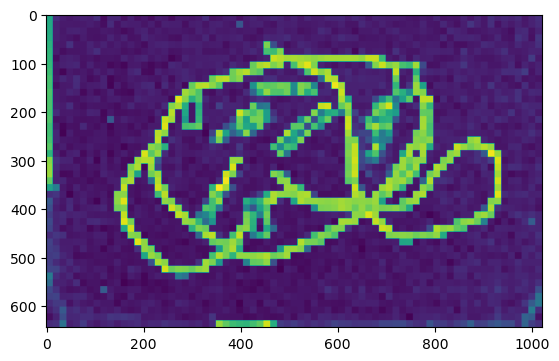

In [16]:
total_features = embed2.unsqueeze(0).cpu().numpy()
patch_h = 644
patch_w = 1022
feat_dim = 384
# First PCA to Seperate Background
# sklearn expects 2d array for traning
total_features = total_features.reshape(patch_h * patch_w, feat_dim) #4(*H*w, 1024)

pca = PCA(n_components=3)
pca.fit(total_features)
pca_features = pca.transform(total_features)

# min_max scale
pca_features[:, 0] = (pca_features[:, 0] - pca_features[:, 0].min()) / \
                     (pca_features[:, 0].max() - pca_features[:, 0].min())
#pca_features = sklearn.processing.minmax_scale(pca_features)

# for i in range(4):
#     plt.subplot(2, 2, i+1)
plt.imshow(pca_features[0*patch_h*patch_w : (1)*patch_h*patch_w, 0].reshape(patch_h, patch_w))

plt.show()